# Trabajo Final de Machine Learning - Ejercicio 1
## Regresion: resistencia a la compresion del hormigon

**Grupo:** F
**Integrantes:** 
Alexis Gonzalez 
Luis
Ale
Georgina
Emi

Este notebook compara tres algoritmos supervisados para predecir la resistencia del hormigon en MPa. Incluye metadata, EDA, preparacion, entrenamiento, evaluacion e interpretacion.

## 1. Metadata y planteamiento

El dataset de UCI contiene 1.030 mezclas de hormigon, ocho variables predictoras cuantitativas y la resistencia de compresion como variable objetivo. Las cantidades de componentes estan expresadas en kg/m3, la edad en dias y la salida en MPa.

La pregunta es: **dada una mezcla y su edad, que resistencia de compresion podemos estimar?**

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid', palette='deep')
RANDOM_STATE = 42

In [ ]:
DATA_PATH = Path('datasets/Concrete_Data.xls')
if not DATA_PATH.exists():
    raise FileNotFoundError(f'No se encontro el dataset: {DATA_PATH.resolve()}')

df = pd.read_excel(DATA_PATH)
df.columns = ['cement', 'slag', 'fly_ash', 'water', 'superplasticizer', 'coarse_aggregate', 'fine_aggregate', 'age_days', 'strength_mpa']
print(f'Dimensiones: {df.shape}')
display(df.head())

Dimensiones: (1030, 9)


,cement,slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age_days,strength_mpa
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


,count,mean,std,min,25%,50%,75%,max
cement,1030.0,281.165631,104.507142,102.000000,192.375000,272.900000,350.000000,540.000000
slag,1030.0,73.895485,86.279104,0.000000,0.000000,22.000000,142.950000,359.400000
fly_ash,1030.0,54.187136,63.996469,0.000000,0.000000,0.000000,118.270000,200.100000
water,1030.0,181.566359,21.355567,121.750000,164.900000,185.000000,192.000000,247.000000
superplasticizer,1030.0,6.203112,5.973492,0.000000,0.000000,6.350000,10.160000,32.200000
coarse_aggregate,1030.0,972.918592,77.753818,801.000000,932.000000,968.000000,1029.400000,1145.000000
fine_aggregate,1030.0,773.578883,80.175427,594.000000,730.950000,779.510000,824.000000,992.600000
age_days,1030.0,45.662136,63.169912,1.000000,7.000000,28.000000,56.000000,365.000000
strength_mpa,1030.0,35.817836,16.705679,2.331808,23.707115,34.442774,46.136287,82.599225


Valores faltantes: 0


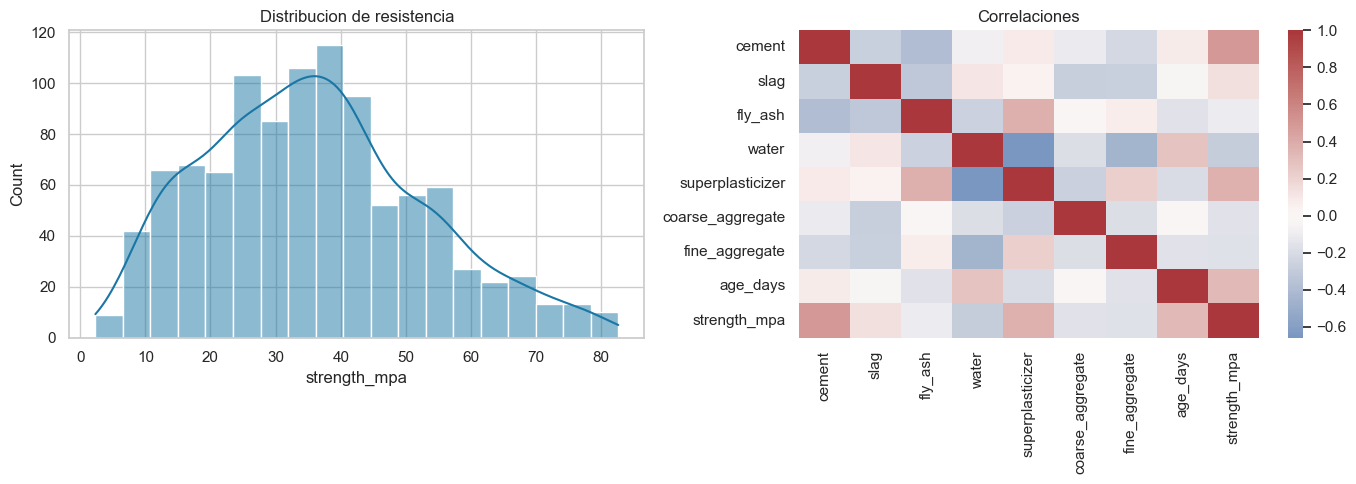

In [3]:
display(df.describe().T)
print('Valores faltantes:', df.isna().sum().sum())
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['strength_mpa'], kde=True, ax=axes[0], color='#1976a5')
axes[0].set_title('Distribucion de resistencia')
sns.heatmap(df.corr(numeric_only=True), cmap='vlag', center=0, ax=axes[1])
axes[1].set_title('Correlaciones')
plt.tight_layout()
plt.show()

## 2. Preparacion y modelos

Separamos un conjunto de prueba estratificado de forma aleatoria. La estandarizacion se coloca dentro de un pipeline para evitar fuga de informacion durante la validacion cruzada.

Modelos: regresion lineal, Random Forest y Gradient Boosting.

In [4]:
X = df.drop(columns='strength_mpa')
y = df['strength_mpa']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE)

models = {
    'Regresion lineal': Pipeline([('scale', StandardScaler()), ('model', LinearRegression())]),
    'Random Forest': RandomForestRegressor(n_estimators=350, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=300, learning_rate=0.04, max_depth=2, random_state=RANDOM_STATE)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    results.append({'Modelo': name, 'MAE (MPa)': mean_absolute_error(y_test, pred), 'RMSE (MPa)': mean_squared_error(y_test, pred) ** 0.5, 'R2': r2_score(y_test, pred)})
results_df = pd.DataFrame(results).sort_values('RMSE (MPa)')
display(results_df.style.format({'MAE (MPa)':'{:.2f}', 'RMSE (MPa)':'{:.2f}', 'R2':'{:.3f}'}))

,Modelo,MAE (MPa),RMSE (MPa),R2
2,Gradient Boosting,4.38,5.58,0.879
1,Random Forest,4.02,5.67,0.875
0,Regresion lineal,7.75,9.80,0.628


In [5]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []
for name, model in models.items():
    scores = -cross_val_score(model, X, y, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1)
    cv_rows.append({'Modelo': name, 'RMSE CV promedio': scores.mean(), 'Desvio CV': scores.std()})
display(pd.DataFrame(cv_rows).sort_values('RMSE CV promedio').style.format({'RMSE CV promedio':'{:.2f}', 'Desvio CV':'{:.2f}'}))

/Users/alexis/Proyectos/Ciencia de datos/ML/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/alexis/Proyectos/Ciencia de datos/ML/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/alexis/Proyectos/Ciencia de datos/ML/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/alexis/Proyectos/Ciencia de datos/ML/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/alexis/Proyectos/Ciencia de datos/ML/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept

,Modelo,RMSE CV promedio,Desvio CV
1,Random Forest,5.29,0.47
2,Gradient Boosting,5.70,0.55
0,Regresion lineal,10.51,0.81


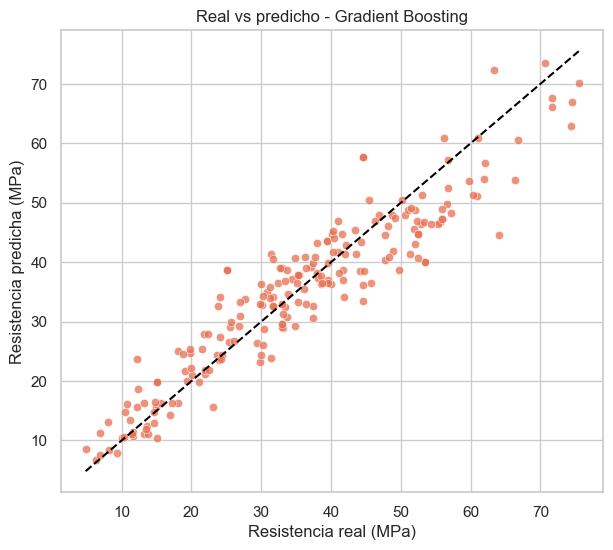

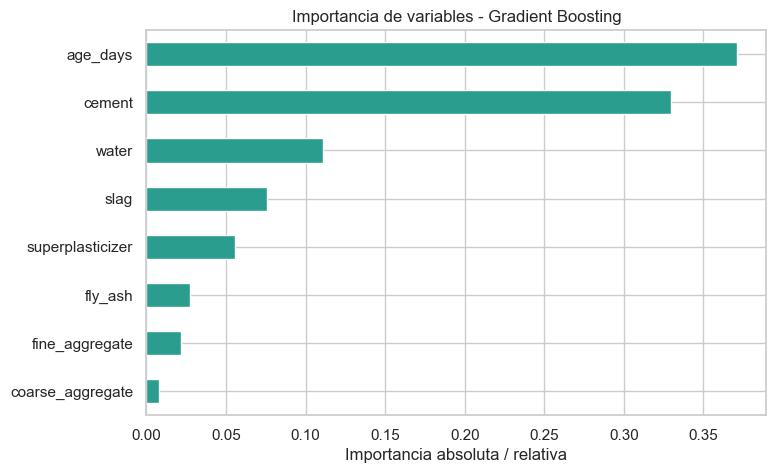

In [6]:
best_name = results_df.iloc[0]['Modelo']
best_model = models[best_name]
best_pred = best_model.predict(X_test)
plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_test, y=best_pred, color='#e76f51', alpha=0.75)
lims = [min(y_test.min(), best_pred.min()), max(y_test.max(), best_pred.max())]
plt.plot(lims, lims, '--', color='black')
plt.xlabel('Resistencia real (MPa)')
plt.ylabel('Resistencia predicha (MPa)')
plt.title(f'Real vs predicho - {best_name}')
plt.show()

if hasattr(best_model, 'feature_importances_'):
    importance = pd.Series(best_model.feature_importances_, index=X.columns).sort_values()
elif 'model' in best_model.named_steps and hasattr(best_model.named_steps['model'], 'coef_'):
    importance = pd.Series(abs(best_model.named_steps['model'].coef_), index=X.columns).sort_values()
else:
    importance = pd.Series(dtype=float)
if not importance.empty:
    importance.plot.barh(figsize=(8, 5), color='#2a9d8f', title=f'Importancia de variables - {best_name}')
    plt.xlabel('Importancia absoluta / relativa')
    plt.show()

## 3. Interpretacion y conclusiones

- El modelo recomendado es el que presenta menor RMSE en el conjunto de prueba y un comportamiento consistente en validacion cruzada.
- La regresion lineal funciona como linea base interpretable; los modelos de ensamble pueden capturar relaciones no lineales entre edad, agua y componentes.
- El grafico real vs. predicho permite verificar sesgo y dispersion. Los puntos alejados de la diagonal representan mezclas cuya resistencia es mas dificil de estimar.
- La importancia de variables indica que atributos contribuyen mas a la prediccion, pero no implica causalidad.

**Limitaciones:** el resultado depende de una unica particion de prueba, de la calidad del dataset historico y no debe sustituir ensayos de laboratorio ni criterios de ingenieria estructural.

## 4. Justificacion de la seleccion de algoritmos e interpretacion

### Objetivo del modelado

El modelo recibe las cantidades de los materiales y la edad del hormigon. Luego entrega una estimacion de resistencia en MPa. Por ejemplo, si una mezcla tiene mas cemento o una edad diferente, el modelo puede aprender que la resistencia esperada tambien cambia.

### Criterio para seleccionar los algoritmos

Se comparan tres enfoques con distintos niveles de complejidad. La regresion lineal funciona como referencia simple e interpretable. Random Forest y Gradient Boosting permiten representar relaciones no lineales entre los componentes de la mezcla y la resistencia. Esta comparacion permite determinar si la complejidad adicional mejora las predicciones de forma consistente.

**Regresion lineal.** Intenta explicar la resistencia sumando el efecto de cada ingrediente. Cada variable aporta una cantidad positiva o negativa a la prediccion. Es facil de explicar, pero puede quedarse corta cuando la relacion entre los ingredientes no es una linea recta.

**Random Forest.** Construye muchos arboles de decision. Cada arbol hace preguntas del tipo “¿la edad es mayor que cierto valor?” o “¿el cemento esta por encima de cierto nivel?”. Luego combina las respuestas de todos los arboles. Suele funcionar bien con relaciones complejas y es menos sensible a valores extremos, aunque es menos facil de explicar como una unica regla.

**Gradient Boosting.** Construye los arboles de forma secuencial. Cada arbol nuevo intenta corregir los errores que cometieron los anteriores. Esto permite capturar patrones sutiles, pero requiere controlar la complejidad para no aprender demasiado los datos historicos.

### Criterios de evaluacion

- **MAE:** error absoluto promedio. Un MAE de 5 significa que, en promedio, la prediccion se aleja 5 MPa de la resistencia real.
- **RMSE:** parecido al MAE, pero castiga mas los errores grandes. Por eso es especialmente util si una prediccion muy equivocada puede ser relevante.
- **R2:** indica cuanto de la variacion de la resistencia logra explicar el modelo. Cuanto mas cerca de 1, mejor; un valor cercano a 0 significa que explica poco mas que usar el promedio.
- **Validacion cruzada:** repite el entrenamiento y la evaluacion con distintas particiones. Sirve para comprobar que el resultado no depende solamente de una division afortunada de los datos.

### Interpretacion de resultados

En el grafico “real vs. predicho”, los puntos cercanos a la diagonal representan buenas predicciones. Los puntos alejados muestran mezclas dificiles de estimar. La grafica de importancia ayuda a identificar que variables fueron mas utiles para el modelo, pero no demuestra por si sola que una variable cause la resistencia.

**Decision final:** se recomienda el modelo que combine menor RMSE en el conjunto de prueba, buen R2 y un resultado estable en validacion cruzada. La prediccion sirve como apoyo al analisis, no reemplaza los ensayos de laboratorio ni la revision de un profesional.